In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [25]:
odr = pd.read_csv("data/age-dependency-ratio-old.csv")
internet = pd.read_csv("data/share-of-individuals-using-the-internet.csv")
rd = pd.read_csv("data/research-spending-gdp.csv")
gdp_pc_long = pd.read_csv("data/gdp-per-capita-worldbank.csv")
tfp = pd.read_csv("data/total-factor-productivity.csv") 
patens = pd.read_csv("data/patent-applications-per-million.csv")
schooling = pd.read_csv("data/average-years-of-schooling-among-adults.csv")

In [26]:
odr = odr.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Age dependency ratio, old (% of working-age population)": "odr"
})

internet = internet.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Share of the population using the Internet": "internet_use"
})

gdp_pc_long = gdp_pc_long.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "GDP per capita": "gdppc",
})

rd = rd.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Research and development expenditure (% of GDP)": "rd"
})

tfp = tfp.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Total factor productivity level": "tfp"
})

patens = patens.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Patent applications per million people": "patens"
})

schooling = schooling.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Both genders": "schooling"
})

In [27]:
start = 2001
end = 2020

lagged_odr = odr.copy()

for df in [odr, tfp, rd, internet]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

odr = odr[(odr["year"] >= start) & (odr["year"] <= end)]
tfp = tfp[(tfp["year"] >= start) & (tfp["year"] <= end)]
rd = rd[(rd["year"] >= start) & (rd["year"] <= end)]
internet = internet[(internet["year"] >= start) & (internet["year"] <= end)]
gdp_pc_long = gdp_pc_long[(gdp_pc_long["year"] >= start) & (gdp_pc_long["year"] <= end)]
patens = patens[(patens["year"] >= start) & (patens["year"] <= end)]

In [28]:
panel2 = internet[["country", "code", "year", "internet_use"]].merge(
    odr[["code", "year", "odr"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    rd[["code", "year", "rd"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    gdp_pc_long[["code", "year", "gdppc"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    tfp[["code", "year", "tfp"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    patens[["code", "year", "patens"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    schooling[["code", "year", "schooling"]],
    on=["code", "year"],
    how="inner"
)

panel2["log_gdp_pc"] = np.log(panel2["gdppc"])
panel2["log_internet_use"] = np.log(panel2["internet_use"])
panel2["log_tfp"] = np.log(panel2["tfp"])
panel2["log_patens"] = np.log(panel2["patens"])

#make a copy of the dataframe
df_mean = panel2.copy()

# remove the year 2002 for each country
df_mean = df_mean[df_mean["year"] != 2001]

# Lav 2-års blokke med start i 2002
df_mean["period_2yr"] = ((df_mean["year"] - 2002) // 2)

# Beregn gennemsnit af odr inden for hvert land og hver 2-års blok
df_mean["odr_2year_mean"] = (
    df_mean
    .groupby(["code", "period_2yr"])["odr"]
    .transform("mean")
)
# Lav 3-års blokke med start i 2002
df_mean["period_3yr"] = ((df_mean["year"] - 2002) // 3)

# Beregn gennemsnit af odr inden for hvert land og hver 3-års blok
df_mean["odr_3year_mean"] = (
    df_mean
    .groupby(["code", "period_3yr"])["odr"]
    .transform("mean")
)

# Hvis du ikke vil beholde hjælpekolonnen
df_mean = df_mean.drop(columns="period_3yr")

# Lav 6-års blokke med start i 2002
df_mean["period_6yr"] = ((df_mean["year"] - 2002) // 6)

# Beregn gennemsnit af odr inden for hvert land og hver 6-års blok
df_mean["odr_6year_mean"] = (
    df_mean
    .groupby(["code", "period_6yr"])["odr"]
    .transform("mean")
)

# Hvis du ikke vil beholde hjælpekolonnen
df_mean = df_mean.drop(columns="period_6yr")

df_mean.loc[
    df_mean["code"] == "DNK",
    ["code", "year", "odr","odr_2year_mean", "odr_3year_mean", "odr_6year_mean"]
].head(10)

panel2 = df_mean.copy()

panel2.head(10)

,country,code,year,internet_use,odr,rd,gdppc,tfp,patens,schooling,log_gdp_pc,log_internet_use,log_tfp,log_patens,period_2yr,odr_2year_mean,odr_3year_mean,odr_6year_mean
1,Argentina,ARG,2002,10.8821,15.660251,0.38886,18571.701,0.977898,18.880156,9.395000,9.829394,2.387119,-0.022350,2.938111,0,15.678688,15.695187,15.776194
2,Argentina,ARG,2003,11.9137,15.697126,0.41013,20005.139,1.042000,20.611967,9.920000,9.903744,2.477689,0.041142,3.025872,0,15.678688,15.695187,15.776194
3,Argentina,ARG,2004,16.0367,15.728183,0.40376,21591.450,1.087289,20.249426,10.010000,9.980053,2.774880,0.083688,3.008126,1,15.756937,15.695187,15.776194
4,Argentina,ARG,2005,17.7206,15.785692,0.42074,23262.408,1.131385,26.876244,10.099999,10.054594,2.874728,0.123443,3.291243,1,15.756937,15.857201,15.776194
5,Argentina,ARG,2006,20.9272,15.861772,0.45216,24877.250,1.176056,25.743198,10.190000,10.121709,3.041050,0.162166,3.248170,2,15.892956,15.857201,15.776194
6,Argentina,ARG,2007,25.9466,15.924140,0.46007,26850.664,1.218432,23.415188,10.299999,10.198046,3.256041,0.197565,3.153385,2,15.892956,15.857201,15.776194
7,Argentina,ARG,2008,28.1126,16.001131,0.47055,27658.484,1.214855,19.814888,10.410000,10.227688,3.336218,0.194625,2.986434,3,16.063613,16.129527,16.366183
8,Argentina,ARG,2009,34.0000,16.126095,0.58398,25747.197,1.131392,15.665222,10.540000,10.156081,3.526361,0.123449,2.751443,3,16.063613,16.129527,16.366183
9,Argentina,ARG,2010,45.0000,16.261354,0.56104,28056.258,1.198247,13.369277,10.600000,10.241967,3.806662,0.180860,2.592959,4,16.340579,16.129527,16.366183
10,Argentina,ARG,2011,51.0000,16.419804,0.56597,29425.760,1.217567,16.486680,10.700000,10.289626,3.931826,0.196855,2.802553,4,16.340579,16.602839,16.366183


## pause

In [29]:
print(panel2[["internet_use", "odr", "rd", "tfp", "gdppc", "schooling"]].isna().sum())

internet_use    0
odr             0
rd              0
tfp             0
gdppc           0
schooling       0
dtype: int64


In [30]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# estimation
model3 = smf.ols(
    "tfp ~ odr  + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr","log_internet_use", "patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0086   0.0045   0.0545
log_internet_use  0.0526   0.0115   0.0000
patens            0.0001   0.0000   0.0293


In [31]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# estimation
model3 = smf.ols(
    "tfp ~ odr  + log_internet_use + log_patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr","log_internet_use", "log_patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "log_patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "log_patens"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0066   0.0046   0.1494
log_internet_use  0.0496   0.0127   0.0001
log_patens       -0.0136   0.0167   0.4160


In [32]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# lav log af BNP pr. capita
df_est["log_gdppc"] = np.log(df_est["gdppc"])

# estimation
model3 = smf.ols(
    "log_tfp ~ odr  + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr","log_internet_use", "patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0105   0.0045   0.0186
log_internet_use  0.0789   0.0170   0.0000
patens            0.0001   0.0001   0.0379


In [33]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# lav log af BNP pr. capita
df_est["log_gdppc"] = np.log(df_est["gdppc"])

# estimation
model3 = smf.ols(
    "log_tfp ~ odr_6year_mean  + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr_6year_mean","log_internet_use", "patens"]],
    "std_err": results3.bse[["odr_6year_mean", "log_internet_use", "patens"]],
    "p_value": results3.pvalues[["odr_6year_mean", "log_internet_use", "patens"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr_6year_mean    0.0099   0.0046   0.0309
log_internet_use  0.0763   0.0171   0.0000
patens            0.0001   0.0001   0.0427


In [34]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr"]],
    "std_err": results3.bse[["odr"]],
    "p_value": results3.pvalues[["odr"]],
})

print(main_results3.round(4))

       coef  std_err  p_value
odr -0.0028   0.0046   0.5446


In [35]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr_6year_mean + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr_6year_mean"]],
    "std_err": results3.bse[["odr_6year_mean"]],
    "p_value": results3.pvalues[["odr_6year_mean"]],
})

print(main_results3.round(4))

                  coef  std_err  p_value
odr_6year_mean -0.0034   0.0047   0.4745


# lagged ODR

In [36]:

lagged = 3
start = 2001 - lagged
end = 2020

lagged_odr = lagged_odr[(lagged_odr["year"] >= start) & (lagged_odr["year"] <= end)]
lagged_odr["odr_lagged"] = lagged_odr.groupby("code")["odr"].shift(lagged)
lagged_odr = lagged_odr.dropna(subset=["odr_lagged"])


panel2 = panel2.merge(
    lagged_odr[["code", "year", "odr_lagged"]],
    on=["code", "year"],
    how="inner"
)

In [37]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr_lagged + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr_lagged"]],
    "std_err": results3.bse[["odr_lagged"]],
    "p_value": results3.pvalues[["odr_lagged"]],
})

print(main_results3.round(4))

             coef  std_err  p_value
odr_lagged -0.003   0.0047   0.5262


In [38]:
# kopi af det færdige balanced panel
df_est = panel2.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr_lagged + log_patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr_lagged", "log_patens"]],
    "std_err": results3.bse[["odr_lagged", "log_patens"]],
    "p_value": results3.pvalues[["odr_lagged", "log_patens"]],
})

print(main_results3.round(4))

              coef  std_err  p_value
odr_lagged -0.0033   0.0046   0.4677
log_patens -0.0198   0.0246   0.4211


## Added variable plot 

In [39]:
res_tfp = smf.ols(
    "log_tfp ~ log_internet_use + log_patens + C(code) + C(year)",
    data=panel2
).fit().resid

res_odr = smf.ols(
    "odr ~ log_internet_use + log_patens + C(code) + C(year)",
    data=panel2
).fit().resid

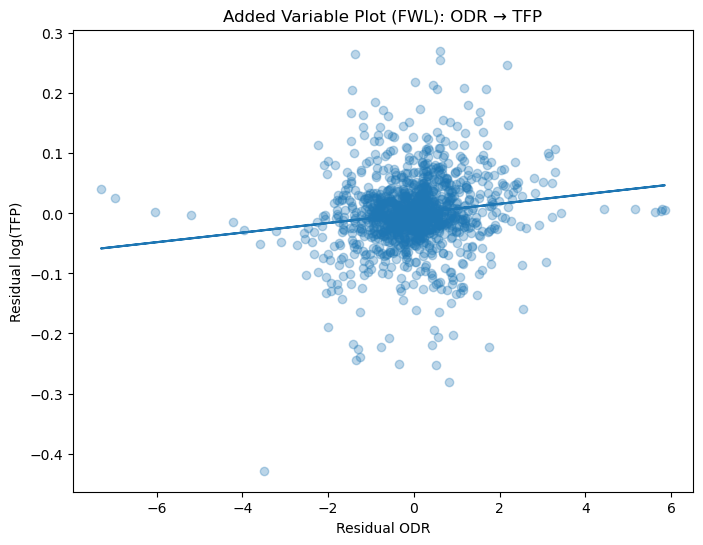

In [40]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(res_odr, res_tfp, alpha=0.3)

# regressionslinje
z = np.polyfit(res_odr, res_tfp, 1)
p = np.poly1d(z)
plt.plot(res_odr, p(res_odr))

plt.xlabel("Residual ODR")
plt.ylabel("Residual log(TFP)")
plt.title("Added Variable Plot (FWL): ODR → TFP")

plt.show()

In [41]:
np.polyfit(res_odr, res_tfp, 1)[0]

0.007999253586002071

Hvert punkt er:

Et land-år, hvor både TFP og ODR er “renset” for:
- landeforskelle (country fixed effects)
- tidsforskelle (year fixed effects)
- andre variable (internet, patenter osv.)

Når ODR stiger med 1 (efter kontrol for alt andet), stiger log(TFP) med ca. 0.008

Illustrerer forholdet mellem aldring og produktivitet inden for landet. Efter fjernelse af faste effekter og andre kontroller forbliver der en positiv hældning, hvilket indikerer, at stigninger i ældreforsørgelseskvoten er forbundet med højere niveauer af total faktorproduktivitet.

## 3-årig samling på hele dataet 

In [42]:
panel2["period_3yr"] = ((panel2["year"] - 2002) // 3)

In [44]:
panel3 = (
    panel2
    .groupby(["code", "period_3yr"])
    .agg({
        "log_tfp": "mean",
        "odr": "mean",
        "log_internet_use": "mean",
        "log_patens": "mean",
        "log_gdp_pc": "mean",
        "schooling": "mean"
    })
    .reset_index()
)

In [45]:
panel3["year"] = panel3["period_3yr"]

In [ ]:
# kopi af det færdige 3-års panel
df_est = panel3.copy()

# estimation
model_3year = smf.ols(
    "log_tfp ~ odr + log_internet_use + log_patens + C(code) + C(year)",
    data=df_est
)

results_3year = model_3year.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# The variables of interest are "odr", "log_internet_use", and "log_patens"
main_results_3year = pd.DataFrame({
    "coef": results_3year.params[["odr", "log_internet_use", "log_patens"]],
    "std_err": results_3year.bse[["odr", "log_internet_use", "log_patens"]],
    "p_value": results_3year.pvalues[["odr", "log_internet_use", "log_patens"]],
})

print(main_results_3year.round(4))

                    coef  std_err  p_value
odr               0.0094   0.0056   0.0930
log_internet_use  0.0798   0.0172   0.0000
log_patens       -0.0216   0.0232   0.3522
